In [1]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import matplotlib.pyplot as plt

helper functions

In [2]:
def get_var_weighted(relvar,trade,Delta=1):
    D = trade.sum(axis=1)
    Hi = relvar.sum(axis=1)
    x = np.sqrt(D/Hi)
    x = x/np.sum(x)
    return x

def get_equal_weights(relvar,trade,Delta=1):
    Q = trade.sum(axis=1)
    N = len(Q)
    return np.ones(N)/N

def get_exact_weights(relvar,trade,Delta=1):
    Q = trade.sum(axis=1)
    Q_scaled = Q / np.mean(Q)

    #scale for stability
    relvar_scaled = relvar / np.linalg.norm(relvar)

    N = len(Q)

    def f_opt(y):
        # Clip y to prevent overflow in exp
        y_clipped = np.clip(y, -50, 0)
        x = np.exp(y_clipped)

        quad = 0.5 * x.T @ relvar_scaled @ x
        recip = np.sum(Q_scaled / x)

        # Ensure positive values before taking log
        if quad <= 0 or recip <= 0:
            return 1e10  # Return large penalty value
        
        # log objective for numerical stability
        return np.log(quad) + np.log(recip)

    #weights sum to 1
    def portfolio_constraint(y):
            y_clipped = np.clip(y, -10, 0)
            x = np.exp(y_clipped)
            return np.sum(x) - 1

    # initial guess is equal weights
    x0 = np.ones(N) / (N)
    y0 = np.log(x0)
    bounds = [(-10, 0)] * N  # bounds to prevent overflow

    # ---- exact solution ----
    res_exact = minimize(
        f_opt,
        y0,
        method="SLSQP",
        bounds=bounds,  # Enable bounds
        constraints=[{'type': 'eq', 'fun': portfolio_constraint}],
        options={"maxiter": 10000, "ftol": 1e-6}  # ftol
    )
    x_opt = np.exp(np.clip(res_exact.x, -10, 0)) #transform back to x
    
    if res_exact.success == False:
        print(res_exact.message)
        print(res_exact.status)
    if f_opt(y0) < f_opt(res_exact.x): #if solver failed for some reason and it worse than equal weights just use equal weights
        x_opt = x0
    return x_opt

In [5]:
# expected costs
def expected_cost_multi(relvar,trade,weight_func,Delta=1):
  Q = trade.sum(axis=1)
  w = weight_func(relvar,trade)
  Hw = w.T @ relvar @ w/2
  totalQ = np.triu(trade).sum()
  return np.sqrt(Delta * Hw * np.sum(Q/w))/(totalQ) * 100

def expected_cost_status_quo(relvar,trade,Delta=1):
  Q = trade.sum(axis=1)
  totalQ = np.triu(trade).sum()
  sigma2 = relvar[0,:]
  return np.sum(np.sqrt(Delta * sigma2 * Q))/(totalQ) * 100

def expected_cost_bilaterals(relvar,trade,Delta=1):
  totalQ = np.triu(trade).sum()
  ratio = np.divide(Delta * relvar,trade,out=np.zeros_like(trade, dtype=float),where=trade != 0)
  term = trade * np.sqrt(ratio)
  # term = trade * np.sqrt(Delta * relvar / trade)
  # term = np.where(trade != 0,trade * np.sqrt(Delta * relvar / trade),0)
  return np.triu(term, k=1).sum()/(totalQ) * 100

Numerical validation

In [6]:
np.random.seed(444)

results = []

num_trials = 500

for N in range(2, 21):

    for trial in range(num_trials):

        # setup
        def generate_factor_covariance(N, epsilon_scale, k_factors=4):
          B = np.random.normal(0, epsilon_scale, size=(N, k_factors)) #sample factors
          Omega = np.eye(k_factors) #indep factors -> identity matrix
          Psi = np.diag(np.random.rand(N)*epsilon_scale**2) #noise on diag for idiosyncratic risk
          cov_matrix = B @ Omega @ B.T + Psi # -> BB^T + Psi

          # add a row and column of zeros for the item with 0 returns
          zeros_row = np.zeros((1, N))
          zeros_col = np.zeros((N + 1, 1))
          cov_matrix = np.vstack((zeros_row,cov_matrix))
          cov_matrix = np.hstack((zeros_col,cov_matrix))
          cov_matrix[0, 0] = 0 # ensure the diagonal element is zero as well

          return cov_matrix

        epsilon_scale = 0.1
        cov = generate_factor_covariance(N, epsilon_scale)
        N_new = N + 1 # adjust N for the new item

        #calculate relvar
        V = np.zeros((N_new, N_new))
        for i in range(N_new):
            for j in range(N_new):
                V[i, j] = cov[i, i] + cov[j, j] - 2 * cov[i, j]
        Delta = 1

        #expected trade volume
        q = np.random.lognormal(mean=0, sigma=1.0, size=N_new)
        q = np.outer(q,q) #make it a symmetric matrix
        q = q * (1 - np.eye(N_new)) # diagonals are zero
        totalQ = np.triu(q).sum() #total volume is sum of upper triangle
        Q = np.sum(q,axis=1)

        def f(x):
            return np.sqrt(Delta * (x.T @ V @ x/2) * (np.sum(Q / x)))/totalQ * 100

        def cost_vehicle():
            return np.sum(np.sqrt(Delta * np.diag(cov) * Q))/totalQ * 100

        x_exact = get_exact_weights(V,q)
        exact_min = f(x_exact)

        # ---- minimize sum_i D_i/w_i H_i
        x_var = get_var_weighted(V,q)
        var_min = f(x_var)

        # ----- equal weights -----
        x_equal = get_equal_weights(V,q)
        equal_min = f(x_equal)

        # ---- status quo ----
        status_quo = expected_cost_status_quo(V,q,Delta)
        # status_quo = cost_vehicle()

        # ---- bilateral ----
        bilaterals = expected_cost_bilaterals(V,q,Delta)

        # store results
        results.append({
            "N": N,
            "trial": trial,
            "x_exact": x_exact.copy(),
            "exact_min": exact_min,
            "x_var": x_var.copy(),
            "var_min": var_min,
            "status_quo": status_quo,
            "totalQ": totalQ,
            "x_equal": x_equal.copy(),
            "equal_min": equal_min,
            "bilaterals": bilaterals
        })

print("Done. Total runs:", len(results))

numerical_df = pd.DataFrame(results)

summary = numerical_df.groupby("N").agg(
    exact_min_mean=("exact_min", "mean"),
    exact_min_std=("exact_min", "std"),
    totalQ_mean=("totalQ", "mean"),
    totalQ_std=("totalQ", "std"),
    var_min_mean=("var_min", "mean"),
    var_min_std=("var_min", "std"),
    status_quo_mean=("status_quo", "mean"),
    status_quo_std=("status_quo", "std"),
    equal_min_mean=("equal_min", "mean"),
    equal_min_std=("equal_min", "std"),
    bilaterals_mean=("bilaterals", "mean"),
    bilaterals_std=("bilaterals", "std")
).reset_index()

Done. Total runs: 9500


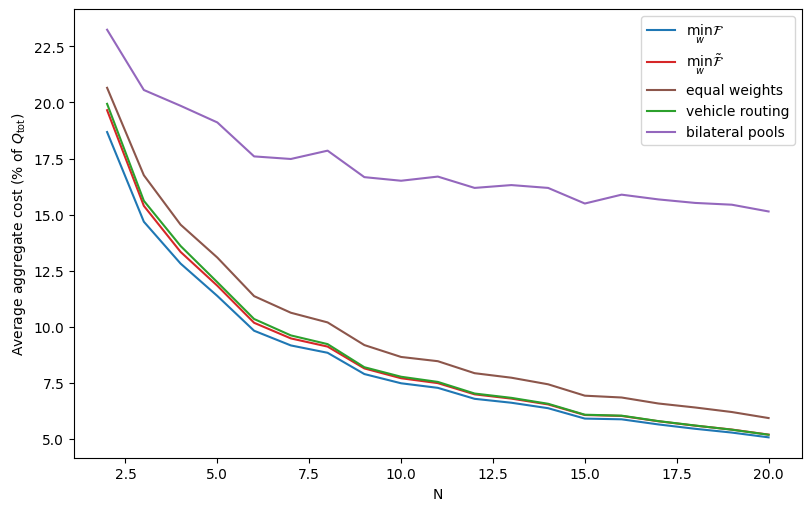

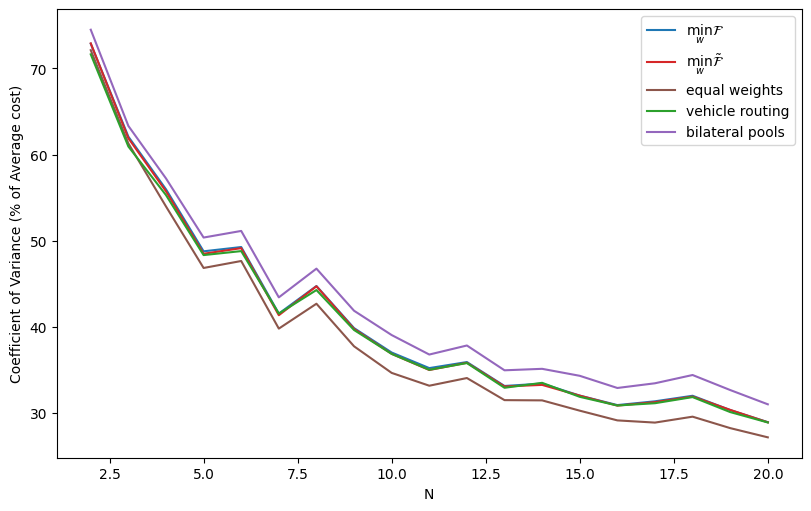

In [8]:
fig1, ax1 = plt.subplots(figsize=(8, 5), constrained_layout=True)

ax1.plot(summary["N"], summary["exact_min_mean"], label=r"$\min_w \mathcal{F}$", color="#1f77b4")
ax1.plot(summary["N"], summary["var_min_mean"], label=r"$\min_w \tilde\mathcal{F}$", color="#d62728")
ax1.plot(summary["N"], summary["equal_min_mean"], label="equal weights", color="#8c564b")
ax1.plot(summary["N"], summary["status_quo_mean"], label="vehicle routing", color="#2ca02c")
ax1.plot(summary["N"], summary["bilaterals_mean"], label="bilateral pools", color="#9467bd")

ax1.set_xlabel("N")
ax1.set_ylabel(r"Average aggregate cost (% of $Q_{\text{tot}}$)")
ax1.legend()

plt.savefig('output/approx_cost_mean.png',dpi=300, bbox_inches="tight")
plt.show()


fig2, ax2 = plt.subplots(figsize=(8, 5), constrained_layout=True)

ax2.plot(summary["N"], summary["exact_min_std"]/summary["exact_min_mean"]*100,
         label=r"$\min_w \mathcal{F}$", color="#1f77b4")
ax2.plot(summary["N"], summary["var_min_std"]/summary["var_min_mean"]*100,
         label=r"$\min_w \tilde\mathcal{F}$", color="#d62728")
ax2.plot(summary["N"], summary["equal_min_std"]/summary["equal_min_mean"]*100,
         label="equal weights", color="#8c564b")
ax2.plot(summary["N"], summary["status_quo_std"]/summary["status_quo_mean"]*100,
         label="vehicle routing", color="#2ca02c")
ax2.plot(summary["N"], summary["bilaterals_std"]/summary["bilaterals_mean"]*100,
         label="bilateral pools", color="#9467bd")

ax2.set_xlabel("N")
ax2.set_ylabel("Coefficient of Variance (% of Average cost)")
ax2.legend()

plt.savefig('output/approx_cost_cv.png',dpi=300, bbox_inches="tight")
plt.show()